# Changing Bases Using Eulerian Transforms

Here is a demonstration of the Eulerian change of basis idea.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

## Infinitesimal Givens

In [2]:
%autoreload 2 
from infidictionary.neural_isometries import InfinitesimalGivensIsometry
from infidictionary.neural_isometries.householder import TimeEvolvingField
from infidictionary.utils import MLPNeuralField

import functools

H = InfinitesimalGivensIsometry(
    coords_dim=2,
    vector_field_partial=functools.partial(
        TimeEvolvingField,
        base_field_partial=functools.partial(
            MLPNeuralField,
            hidden_dims=dict(a=64, b=64),
            activation=torch.nn.ReLU,
        ),
    ),
    use_adjoint=False,
    method='euler_householder',
    rtol=1e-5,
    atol=1e-6,
    start_time=0.0,
    end_time=1.0,
    initial_diffeomorphism=None
).to(device)



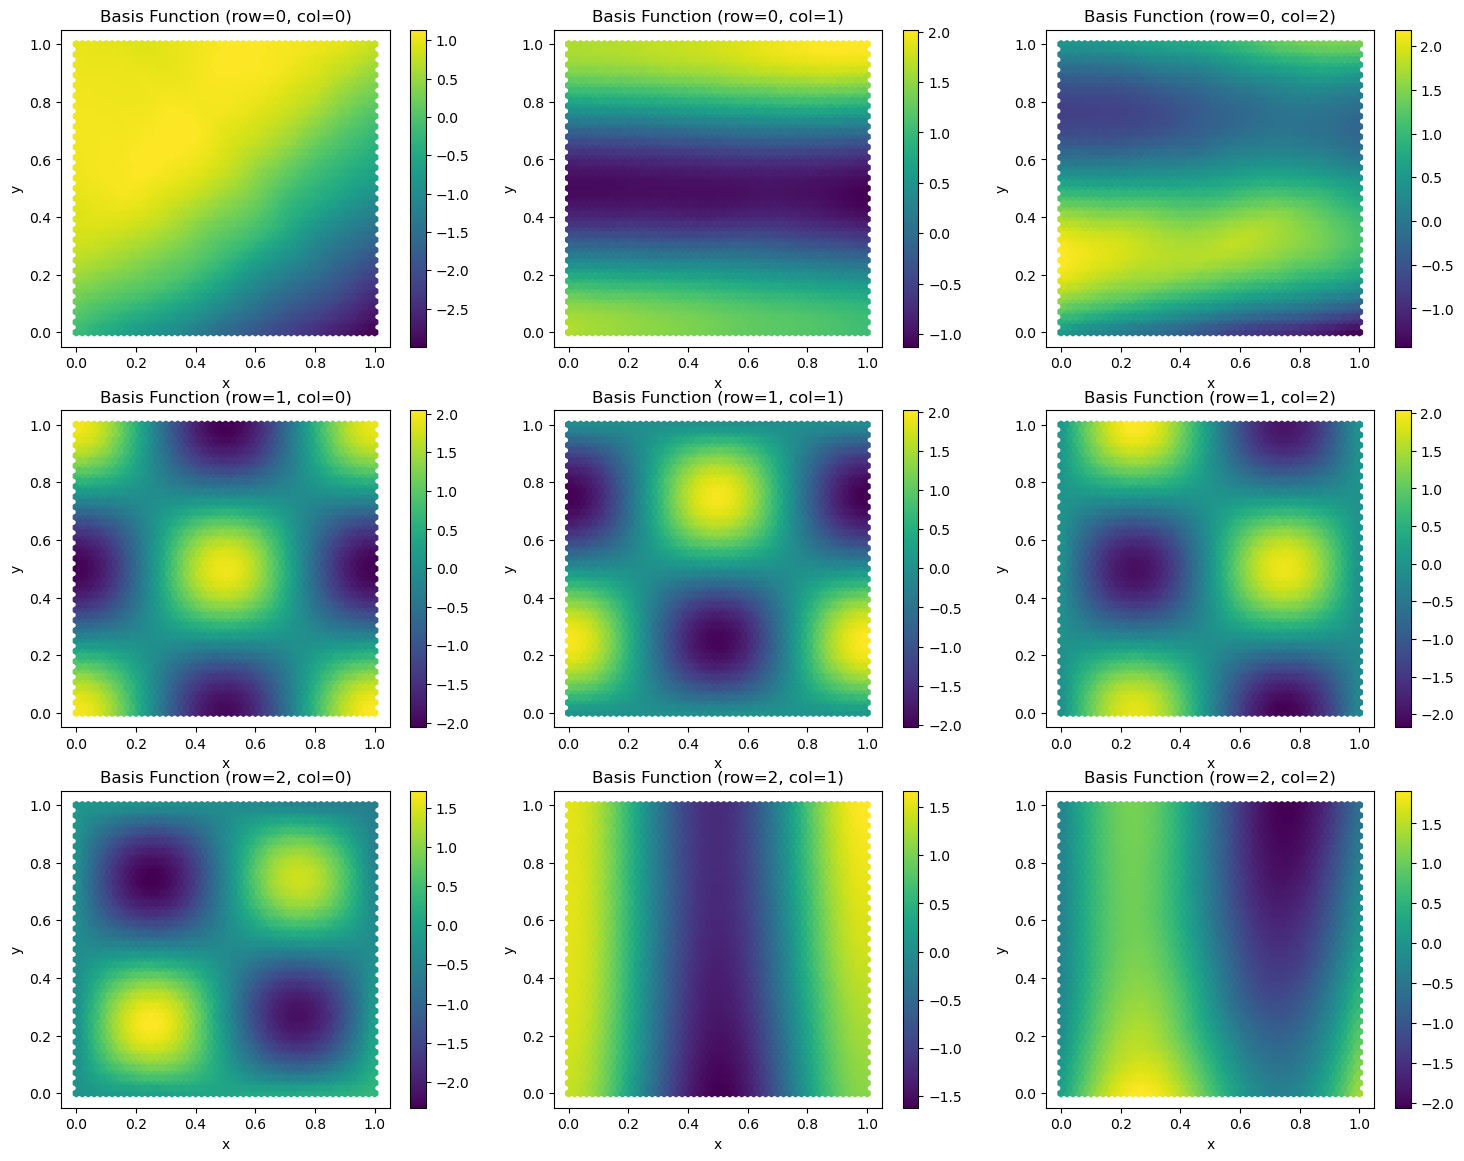

In [3]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary

fourier_basis = FourierDictionary()
indices = [
    [0, 1, 2],
    [3, 4, 5], 
    [6, 7, 8],
]
indices_tensorized = torch.tensor(indices).to(device).flatten()

# seed everything for reproducibility
torch.manual_seed(0)
N = 50000
end_time = 5.5
all_deformed_vals = []
all_vals = []
xy = fourier_basis.sample_from_domain(N).to(device)
all_vals = fourier_basis.get_atom(xy, indices_tensorized)
all_vals_transformed = H.transform(
    initial_dictionary=fourier_basis,
    atom_indices=indices_tensorized,
    coords=xy,
    device=device,
    mode='pullback',
    num_steps=10,
)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,14))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = indices[row][col]
        # approximate integral by monte carlo
        ax.hexbin(
            xy[:,0].detach().cpu(), 
            xy[:,1].detach().cpu(), 
            C=all_vals_transformed[row * 3 + col].detach().cpu(), 
            gridsize=50, 
            cmap='viridis',
        ) 
        plt.colorbar(mappable=ax.collections[0], ax=ax)
        ax.set_title(f'Basis Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()


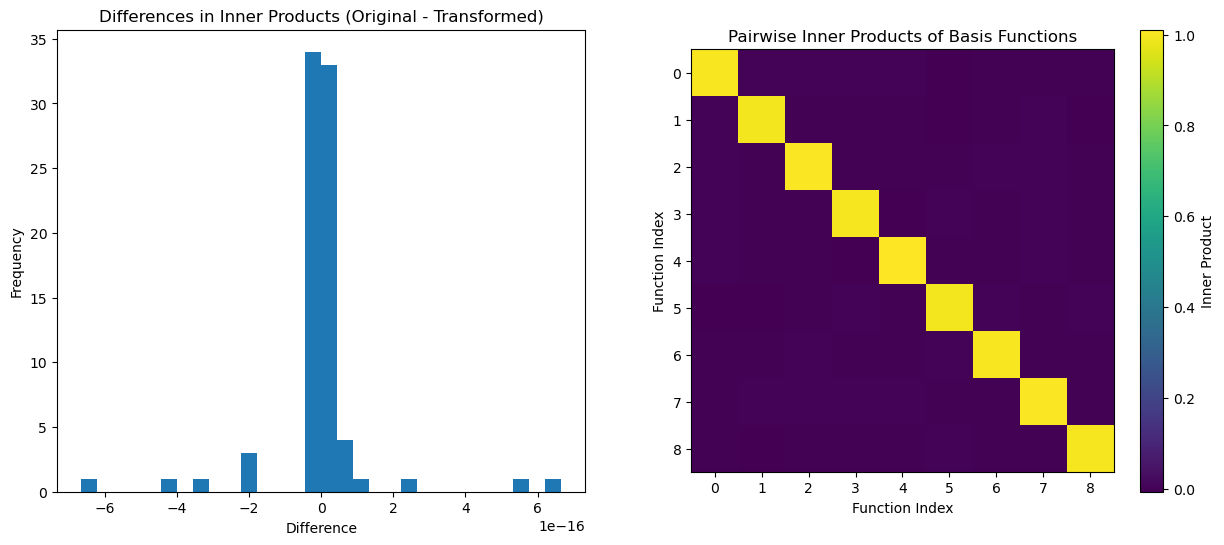

In [4]:
# compute pairwise inner products
inner_products = np.zeros((9, 9))
inner_products_transformed = np.zeros((9, 9))
fig, axes = plt.subplots(figsize=(15, 6), nrows=1, ncols=2)
inner_products_transformed = (all_vals_transformed @ all_vals_transformed.T / N).detach().cpu()
inner_products = (all_vals @ all_vals.T / N).detach().cpu()
# heatmap of inner products
m = axes[1].imshow(inner_products_transformed)
# axes[1].
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Pairwise Inner Products of Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_transformed
axes[0].hist(diffs.flatten(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Transformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()


## Low rank Cayley



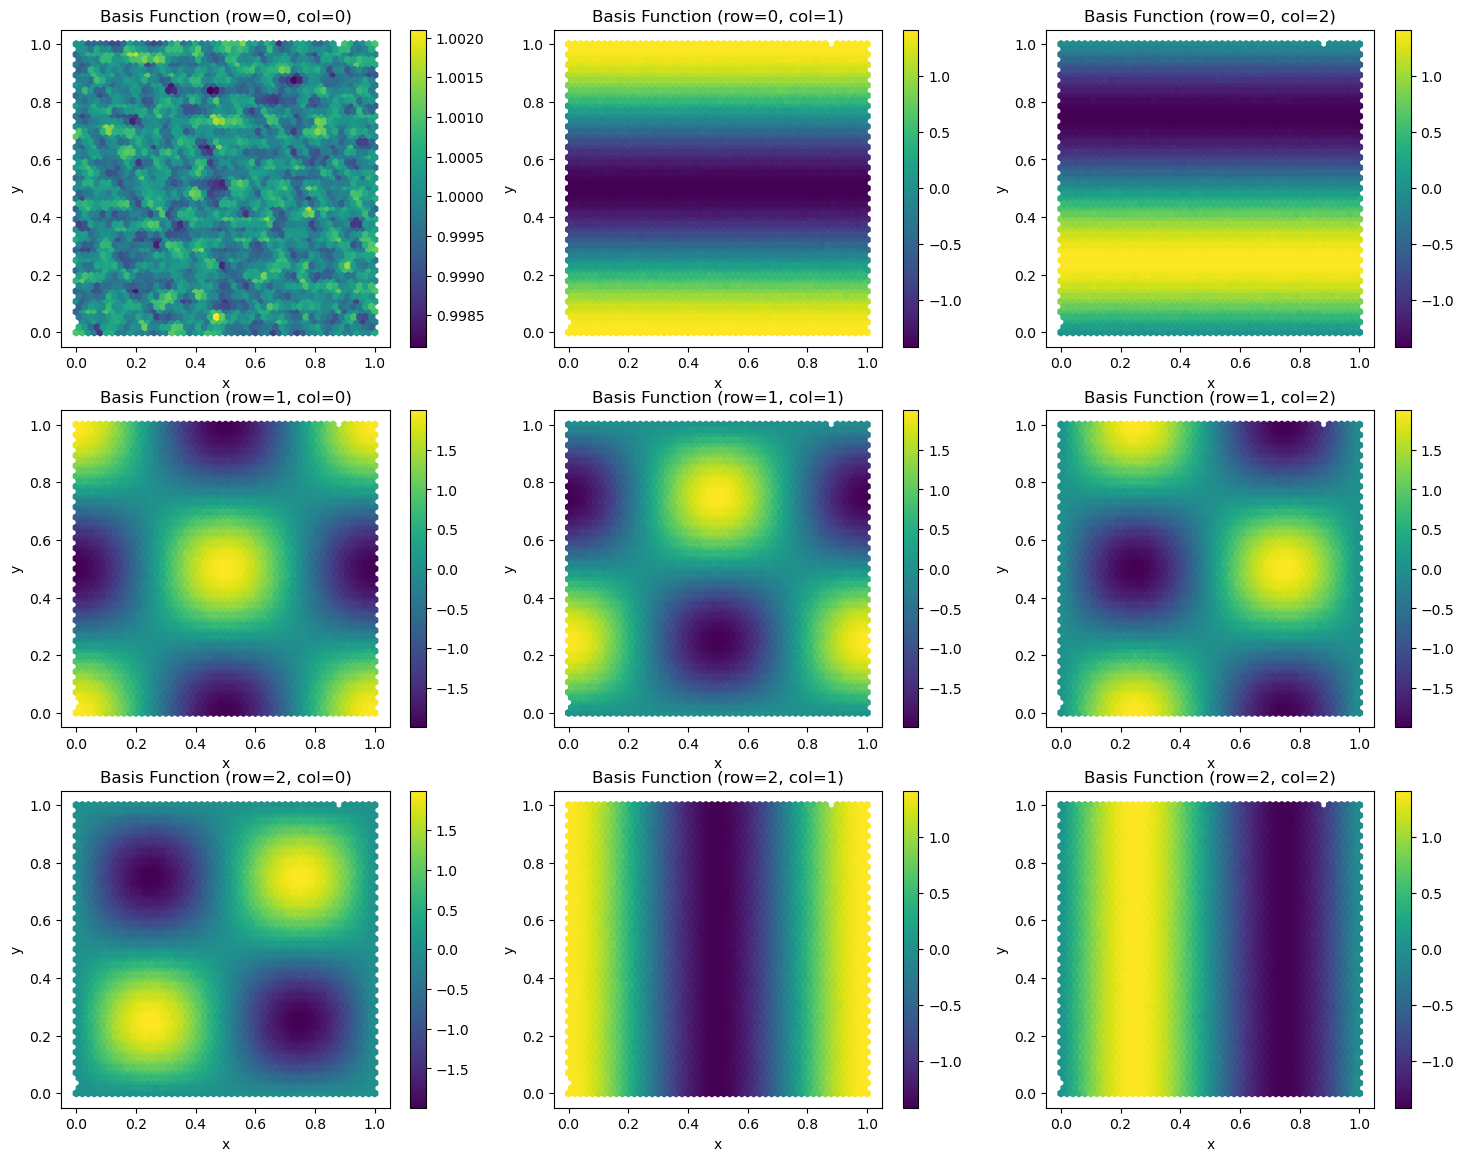

In [ ]:
%autoreload 2 
from infidictionary.neural_isometries import LowRankEulerianIsometry
from infidictionary.neural_isometries.low_rank_eulerian import EulerianDynamics, TimeEvolvingField
from infidictionary.utils import MLPNeuralField, NeuralField, FFNeuralField
from infidictionary.dictionaries import FourierDictionary
import functools
import torch

low_rank_isometry = LowRankEulerianIsometry(
    n_steps=20,
    eulerian_dynamics=EulerianDynamics(
        field_partial=functools.partial(
            FFNeuralField,
            n_features=64,
            sigma=10.0,
            hidden_dims=[64, 64],
            activation=torch.nn.ReLU,
        ),
        coord_dims=2, 
        value_dims=1,
    ),
).to(device)


fourier_basis = FourierDictionary()
indices = [
    [0, 1, 2],
    [3, 4, 5], 
    [6, 7, 8],
]
indices_tensorized = torch.tensor(indices).to(device).flatten()

# seed everything for reproducibility
torch.manual_seed(0)
N = 25000
end_time = 5.5
all_deformed_vals = []
all_vals = []
xy = fourier_basis.sample_from_domain(N).to(device)
all_vals = fourier_basis.get_atom(xy, indices_tensorized)
all_vals_transformed = low_rank_isometry.transform(
    initial_dictionary=fourier_basis,
    atom_indices=indices_tensorized,
    coords=xy,
    device=device,
    mode='pullback',
)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,14))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = indices[row][col]
        # approximate integral by monte carlo
        ax.hexbin(
            xy[:,0].detach().cpu(), 
            xy[:,1].detach().cpu(), 
            C=all_vals_transformed[row * 3 + col].detach().cpu(), 
            gridsize=50, 
            cmap='viridis',
        ) 
        plt.colorbar(mappable=ax.collections[0], ax=ax)
        ax.set_title(f'Basis Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()


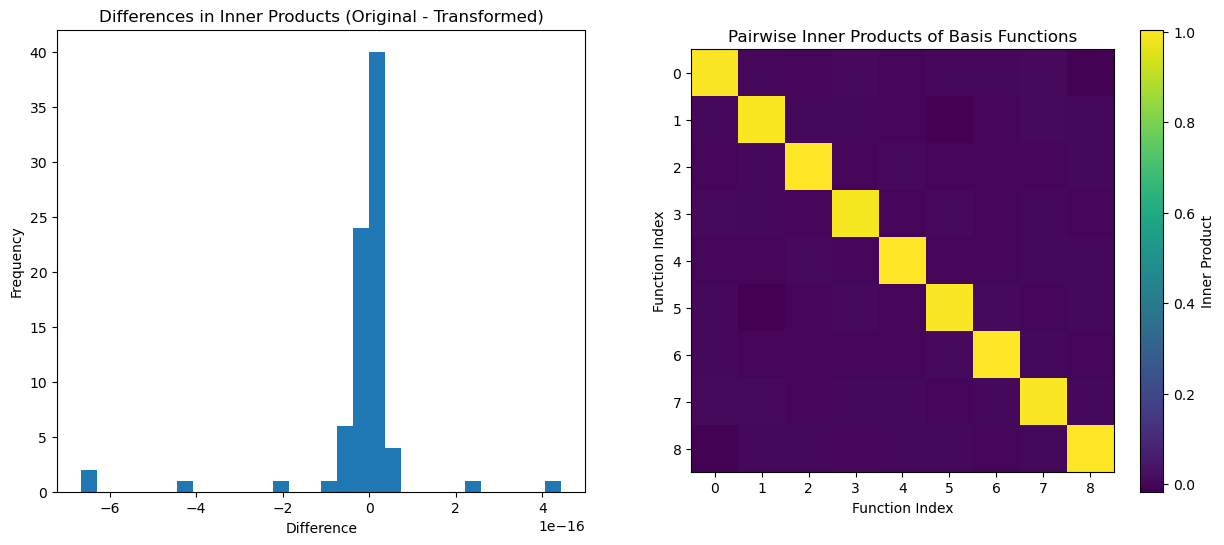

In [9]:
# compute pairwise inner products
inner_products = np.zeros((9, 9))
inner_products_transformed = np.zeros((9, 9))
fig, axes = plt.subplots(figsize=(15, 6), nrows=1, ncols=2)
inner_products_transformed = (all_vals_transformed @ all_vals_transformed.T / N).detach().cpu()
inner_products = (all_vals @ all_vals.T / N).detach().cpu()
# heatmap of inner products
m = axes[1].imshow(inner_products)
# axes[1].
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Pairwise Inner Products of Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_transformed
axes[0].hist(diffs.flatten(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Transformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()
